# Ranking Chicago Attractions by Wikipedia Pageviews

The OSM attractions feed has no notion of importance: the Bean and a small
neighborhood gallery are equal rows. This notebook attaches a popularity score
to each attraction using Wikipedia pageviews, which serve as a public,
keyless proxy for visitor interest.

**Pipeline:**
1. Pull tourist attractions from the Overpass API (same query the app uses).
2. Resolve each attraction to an English Wikipedia article. Primary source is
   the `wikipedia` tag on the OSM element itself. Fallback is Wikipedia's
   geosearch API within 300m, accepted only when the article title is a close
   string match to the attraction name.
3. Pull monthly pageviews for the last 12 complete months from the Wikimedia
   REST API and average them.
4. Export `data/attractions.csv`. The app prefers this file over a live
   Overpass call and unlocks the popularity filter and cluster ranking.

Pageviews measure reading interest rather than foot traffic. The two track
each other well at the top (Millennium Park, Willis Tower), though a place can
be famous to read about and mediocre to visit. The score is used for ranking
and filtering and is never shown as visitor counts.

In [1]:
import io
import json
import sys
import time
import urllib.request
import urllib.parse
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from difflib import SequenceMatcher

sys.path.append("..")
from helpers import OVERPASS_ENDPOINTS, OVERPASS_QUERY, _osm_category, _wiki_title, _display_name

HEADERS = {"User-Agent": "ChicagoTransitGuide/1.0 (https://github.com/lewilliam888; lewilliam888@gmail.com)"}
OUT_PATH = "../data/attractions.csv"


def get_json(url, data=None, retries=3):
    for attempt in range(retries):
        try:
            req = urllib.request.Request(url, data=data, headers=HEADERS)
            with urllib.request.urlopen(req, timeout=120) as resp:
                return json.loads(resp.read().decode())
        except urllib.error.HTTPError as e:
            if e.code in (429, 503) and attempt < retries - 1:
                wait = int(e.headers.get("Retry-After") or 2 ** (attempt + 1))
                time.sleep(min(wait, 30))
                continue
            raise
        except Exception:
            if attempt < retries - 1:
                time.sleep(2 ** (attempt + 1))
                continue
            raise

2026-08-04 15:16:39.306 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-08-04 15:16:39.307 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-08-04 15:16:39.307 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-08-04 15:16:40.916 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-08-04 15:16:40.917 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-08-04 15:16:40.918 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


## 1. Attractions from Overpass

In [2]:
payload = None
for endpoint in OVERPASS_ENDPOINTS:
    try:
        payload = get_json(endpoint, data=urllib.parse.urlencode({"data": OVERPASS_QUERY}).encode())
        break
    except Exception as e:
        print(f"{endpoint} failed: {e}")
assert payload is not None, "all Overpass servers busy, retry in a minute"

rows = []
for el in payload.get("elements", []):
    tags = el.get("tags", {})
    name = tags.get("name")
    category = _osm_category(tags)
    if not name or category is None:
        continue
    lat = el.get("lat") or el.get("center", {}).get("lat")
    lon = el.get("lon") or el.get("center", {}).get("lon")
    if lat is None or lon is None:
        continue
    rows.append({
        "name": _display_name(tags),
        "category": category,
        "latitude": float(lat),
        "longitude": float(lon),
        "wiki_title": _wiki_title(tags),
        "wikidata": tags.get("wikidata"),
    })

df = pd.DataFrame(rows)
has_wd = df["wikidata"].notna()
df = pd.concat([df[has_wd].drop_duplicates("wikidata"), df[~has_wd]])
df = df.drop_duplicates(["name", "category"]).reset_index(drop=True)
print(f"{len(df)} attractions")
df["category"].value_counts()

432 attractions


category
Iconic Attractions     195
Museums & Galleries    159
Parks & Outdoors        64
Zoos & Family           14
Name: count, dtype: int64

## 2. Resolve Wikipedia articles

The `wikipedia` tag covers the well-mapped attractions. For the rest, search
articles within 300m of the coordinates and accept the best title only when
its string similarity to the attraction name is at least 0.6. That threshold
keeps "Millennium Park" matching "Millennium Park" while rejecting an
adjacent skyscraper's article.

In [3]:
def geosearch_match(name, lat, lon, radius=300):
    url = ("https://en.wikipedia.org/w/api.php?action=query&list=geosearch"
           f"&gscoord={lat}%7C{lon}&gsradius={radius}&gslimit=5&format=json")
    try:
        result = get_json(url)
        candidates = result.get("query", {}).get("geosearch", [])
    except Exception as e:
        GEO_ERRORS.append(f"{name}: {e}")
        return None
    best, best_score = None, 0.0
    for c in candidates:
        score = SequenceMatcher(None, name.lower(), c["title"].lower()).ratio()
        if score > best_score:
            best, best_score = c["title"], score
    return best if best_score >= 0.6 else None


GEO_ERRORS = []
missing = df["wiki_title"].isna()
print(f"{(~missing).sum()} titles from OSM tags, resolving {missing.sum()} via geosearch...")
for i in df.index[missing]:
    df.loc[i, "wiki_title"] = geosearch_match(
        df.loc[i, "name"], df.loc[i, "latitude"], df.loc[i, "longitude"])
    time.sleep(0.25)

print(f"matched: {df['wiki_title'].notna().sum()} of {len(df)}")
if GEO_ERRORS:
    print(f"{len(GEO_ERRORS)} geosearch errors, first: {GEO_ERRORS[0]}")

296 titles from OSM tags, resolving 136 via geosearch...


matched: 308 of 432


## 2b. Validate matches with article coordinates

A name match alone is too weak. A menorah sculpture matches the article
"Menorah" and inherits the fame of the concept. The filter: the matched
article must itself carry coordinates within 2 km of the attraction. Concept
articles have no coordinates, or coordinates on another continent, so they
fail this check. The cost is losing a few legitimate articles that lack
coordinates, which fits the precision-over-recall approach used throughout.

In [4]:
from math import radians, sin, cos, asin, sqrt


def km_between(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    a = sin((lat2-lat1)/2)**2 + cos(lat1)*cos(lat2)*sin((lon2-lon1)/2)**2
    return 2 * 6371 * asin(sqrt(a))


def article_coords(titles):
    url = ("https://en.wikipedia.org/w/api.php?action=query&prop=coordinates"
           "&colimit=max&redirects=1&format=json&titles="
           + urllib.parse.quote("|".join(titles)))
    result = get_json(url).get("query", {})
    red = {r["to"]: r["from"] for r in result.get("redirects", [])}
    norm = {n["to"]: n["from"] for n in result.get("normalized", [])}
    out = {}
    for page in result.get("pages", {}).values():
        t = page.get("title")
        c = page.get("coordinates")
        val = (c[0]["lat"], c[0]["lon"]) if c else None
        orig = red.get(t, t)
        orig = norm.get(orig, orig)
        out[t] = val
        out[orig] = val
    return out


titles = df.loc[df["wiki_title"].notna(), "wiki_title"].unique().tolist()
coord_map = {}
for i in range(0, len(titles), 50):
    coord_map.update(article_coords(titles[i:i+50]))
    time.sleep(0.25)

rejected = 0
for i in df.index[df["wiki_title"].notna()]:
    c = coord_map.get(df.loc[i, "wiki_title"])
    if c is None or km_between(c[0], c[1], df.loc[i, "latitude"], df.loc[i, "longitude"]) > 2:
        df.loc[i, "wiki_title"] = None
        rejected += 1
print(f"rejected {rejected} matches (no article coordinates within 2 km)")
print(f"{df['wiki_title'].notna().sum()} validated matches remain")

rejected 41 matches (no article coordinates within 2 km)
267 validated matches remain


## 3. Pageviews

Monthly views for the last 12 complete months, averaged. Articles without
pageview data (404s) keep NaN and sort last in the app.

In [5]:
end = date.today().replace(day=1)                      # first of current month
start = end.replace(year=end.year - 1)                 # 12 months back
fmt = lambda d: d.strftime("%Y%m%d") + "00"


def monthly_views(title):
    quoted = urllib.parse.quote(title.replace(" ", "_"), safe="")
    url = ("https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
           f"en.wikipedia/all-access/user/{quoted}/monthly/{fmt(start)}/{fmt(end)}")
    try:
        items = get_json(url).get("items", [])
        return float(np.mean([x["views"] for x in items])) if items else np.nan
    except Exception as e:
        PV_ERRORS.append(f"{title}: {e}")
        return np.nan


PV_ERRORS = []
titled = df["wiki_title"].notna()
print(f"fetching pageviews for {titled.sum()} articles...")
views = {}
for title in df.loc[titled, "wiki_title"].unique():
    views[title] = monthly_views(title)
    time.sleep(0.25)

df["monthly_views"] = df["wiki_title"].map(views)
print(f"got views for {df['monthly_views'].notna().sum()} attractions")
if PV_ERRORS:
    print(f"{len(PV_ERRORS)} pageview errors, first: {PV_ERRORS[0]}")

fetching pageviews for 267 articles...


got views for 267 attractions


## 4. Sanity check: does the ranking look like Chicago?

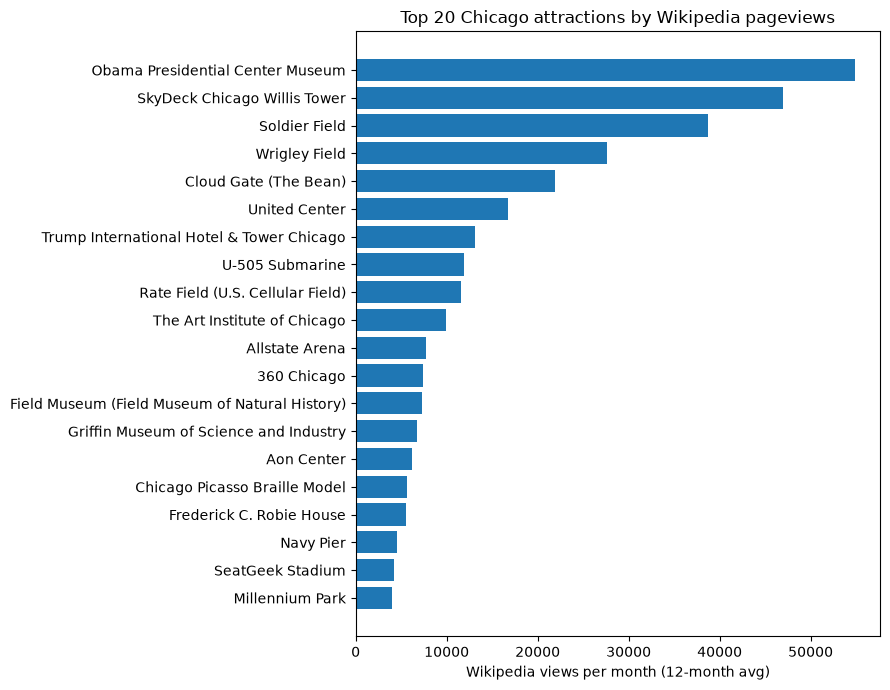

,name,category,monthly_views
0,Obama Presidential Center Museum,Museums & Galleries,54880.461538
1,SkyDeck Chicago Willis Tower,Iconic Attractions,46962.153846
2,Soldier Field,Iconic Attractions,38705.461538
3,Wrigley Field,Iconic Attractions,27644.461538
4,Cloud Gate (The Bean),Iconic Attractions,21956.538462
5,United Center,Iconic Attractions,16792.615385
6,Trump International Hotel & Tower Chicago,Iconic Attractions,13118.769231
7,U-505 Submarine,Iconic Attractions,11858.692308
8,Rate Field (U.S. Cellular Field),Iconic Attractions,11533.000000
9,The Art Institute of Chicago,Museums & Galleries,9902.000000


In [6]:
top = df.nlargest(20, "monthly_views")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top["name"][::-1], top["monthly_views"][::-1])
ax.set_xlabel("Wikipedia views per month (12-month avg)")
ax.set_title("Top 20 Chicago attractions by Wikipedia pageviews")
plt.tight_layout()
plt.show()

top[["name", "category", "monthly_views"]].reset_index(drop=True)

In [7]:
df.groupby("category")["monthly_views"].agg(
    attractions="size",
    with_views=lambda s: s.notna().sum(),
    median_views="median",
    max_views="max",
).round(0)

,attractions,with_views,median_views,max_views
category,,,,
Iconic Attractions,195,161,324.0,46962.0
Museums & Galleries,159,43,289.0,54880.0
Parks & Outdoors,64,61,94.0,4029.0
Zoos & Family,14,2,1342.0,2173.0


## 5. Export

In [8]:
out = df[["name", "category", "latitude", "longitude", "wiki_title", "monthly_views"]]
out.to_csv(OUT_PATH, index=False)
print(f"wrote {len(out)} rows to {OUT_PATH}")

wrote 432 rows to ../data/attractions.csv


## Limitations

- Pageviews measure reading interest, not visits. Sports venues and buildings
  with famous histories over-index; purely visual attractions under-index.
- Unmatched attractions (no OSM tag, no confident geosearch match) get NaN
  and are excluded from popularity filtering rather than guessed.
- OSM coverage and tagging vary by neighborhood. A missing attraction here is
  missing from the app.
- The coordinate check drops articles that lack coordinates even when
  the match is right, so some famous objects rank as unmatched.
- The 0.6 similarity threshold trades recall for precision. Spot-check the
  matches before trusting a new export.